# Atencion simple con NumPy

Frase de ejemplo: **el perro mordio al hombre**

Objetivo: construir un ejemplo pequeno de self-attention paso a paso.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.options.display.float_format = '{:.4f}'.format
np.random.seed(23)

## 1) Tokens y embeddings base

Tomamos la frase de la imagen y usamos embeddings de dimension 4.

In [2]:
tokens = ['el', 'perro', 'mordio', 'al', 'hombre']

X_embed = np.array([
    [0.10, 0.20, 0.30, 0.40],  # el
    [0.50, 0.10, 0.00, 0.20],  # perro
    [0.00, 0.30, 0.10, 0.50],  # mordio
    [0.20, 0.20, 0.20, 0.00],  # al
    [0.40, 0.00, 0.20, 0.10],  # hombre
], dtype=np.float32)

df_embed = pd.DataFrame(X_embed, index=tokens, columns=[f'd{i}' for i in range(4)])
df_embed

,d0,d1,d2,d3
el,0.1000,0.2000,0.3000,0.4000
perro,0.5000,0.1000,0.0000,0.2000
mordio,0.0000,0.3000,0.1000,0.5000
al,0.2000,0.2000,0.2000,0.0000
hombre,0.4000,0.0000,0.2000,0.1000


## 2) Embeddings posicionales (ejemplo manual)

Sumamos una codificacion posicional sencilla para distinguir orden.

In [3]:
X_pos = np.array([
    [ 0.30, -0.90, -0.60,  0.80],
    [-0.60,  0.80, -0.90,  0.15],
    [ 0.80, -0.50, -0.90,  0.50],
    [-0.95,  0.20, -0.40, -0.90],
    [ 0.95,  0.16,  0.20, -0.95],
], dtype=np.float32)

X = X_embed + X_pos
df_x = pd.DataFrame(X, index=tokens, columns=[f'd{i}' for i in range(4)])
df_x

,d0,d1,d2,d3
el,0.4000,-0.7000,-0.3000,1.2000
perro,-0.1000,0.9000,-0.9000,0.3500
mordio,0.8000,-0.2000,-0.8000,1.0000
al,-0.7500,0.4000,-0.2000,-0.9000
hombre,1.3500,0.1600,0.4000,-0.8500


## 3) Proyecciones Q, K, V

Definimos matrices de proyeccion y calculamos Queries, Keys y Values.

In [4]:
d_model = 4
d_k = 3
d_v = 3

W_q = np.random.randn(d_model, d_k) * 0.1
W_k = np.random.randn(d_model, d_k) * 0.1
W_v = np.random.randn(d_model, d_v) * 0.1

Q = X @ W_q
K = X @ W_k
V = X @ W_v

print('Q shape:', Q.shape)
print('K shape:', K.shape)
print('V shape:', V.shape)

Q shape: (5, 3)
K shape: (5, 3)
V shape: (5, 3)


In [ ]:
V

array([[ 0.1147, -0.1297, -0.0232],
       [ 0.0532, -0.0352, -0.1981],
       [ 0.0776, -0.1711, -0.1127],
       [-0.1729,  0.1185,  0.0079],
       [-0.0579, -0.0609,  0.0489]])

Exception in callback BaseAsyncIOLoop._handle_events(908, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(908, 1)>
Traceback (most recent call last):
  File "C:\Users\jose.rodriguezb\AppData\Roaming\uv\python\cpython-3.11.14-windows-x86_64-none\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\tornado\platform\asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\zmq

## 4) Attention scores y pesos

Aplicamos scaled dot-product attention: $softmax(QK^T / \sqrt{d_k})$.

In [5]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

scores = (Q @ K.T) / np.sqrt(d_k)
pesos = softmax(scores)

df_pesos = pd.DataFrame(pesos, index=tokens, columns=tokens)
df_pesos

,el,perro,mordio,al,hombre
el,0.2035,0.2029,0.2040,0.1971,0.1925
perro,0.2038,0.2031,0.2056,0.1951,0.1924
mordio,0.2049,0.2036,0.2063,0.1948,0.1905
al,0.1967,0.2000,0.1966,0.2032,0.2034
hombre,0.1991,0.1955,0.1986,0.1999,0.2069


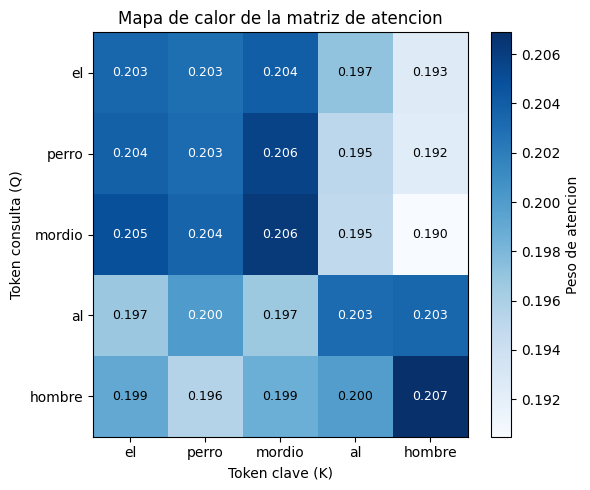

In [6]:
plt.figure(figsize=(6, 5))
im = plt.imshow(pesos, cmap='Blues', aspect='auto')
plt.colorbar(im, label='Peso de atencion')

plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel('Token clave (K)')
plt.ylabel('Token consulta (Q)')
plt.title('Mapa de calor de la matriz de atencion')

for i in range(len(tokens)):
    for j in range(len(tokens)):
        color_txt = 'white' if pesos[i, j] >= np.mean(pesos) else 'black'
        plt.text(j, i, f'{pesos[i, j]:.3f}', ha='center', va='center', color=color_txt, fontsize=9)

plt.tight_layout()
plt.show()

### Como se lee este mapa de calor

- Cada fila es el token que consulta (Q).
- Cada columna es el token al que se presta atencion (K).
- El valor en la celda (fila i, columna j) indica cuanta atención pone el token i al token j.
- Colores mas intensos y valores mas altos significan mayor atencion.

## 5) Salida de atencion

La representacion final por token es: $Attention(Q,K,V)=softmax(QK^T/\sqrt{d_k})V$.

In [7]:
salida = pesos @ V
df_salida = pd.DataFrame(salida, index=tokens, columns=[f'v{i}' for i in range(d_v)])
df_salida

,v0,v1,v2
el,0.0047,-0.0568,-0.0569
perro,0.0053,-0.0574,-0.0572
mordio,0.0056,-0.0575,-0.0575
al,0.0016,-0.0545,-0.0548
hombre,0.0021,-0.0556,-0.0540
